# Lab 1 DS & AI - DQ
# Influence of Data Quality on Machine Learning performance

_Don't forget to put your names and student numbers here_

**Authors**: 

In this lab we will explore different data quality problems and their possible effect on classification or regression tasks. To help you to start quickly with this lab, the notebook below already implements a basic Regression and Classification task. You can do the exercises by taking this code and modify/extend it. 

## Import Relevant Libraries

In [21]:
# Uncomment if needed and restart the Kernel after installation
# %pip install seaborn

In [22]:
# If you get an error on the import of the seaborn package below, then you need to install
# it first with 'pip' in the above box. Uncomment the '%pip' line, execute the cell, comment it again,
# and do a restart of the kernel (top Menu bar, menu 'Kernel', menu-item 'Restart Kernel'

import matplotlib.pyplot as plt
from scipy.io import arff
import seaborn as sns
import pandas as pd
import warnings
import os

warnings.filterwarnings("ignore", module="matplotlib\..*")

## Load Data
Some files are stored as an arff file, for which you can use the function below to load it into a pandas dataframe. An ARFF file can be viewed with a text editor; please do because it often contains documentation among other things about the meaning of the various attributes.

In [23]:
def load_arff(file_path):
    '''Return a pandas dataframe and meta data from an arff file.'''
    ar, meta = arff.loadarff(file_path)
    return pd.DataFrame(ar), meta

# Regression
---
In this case we will look at a data set containing the stock prices for 10 aerospace companies for an regression analysis. The goal is to predict the stock price of one company (company 10) given the prices of the other companies.

### Load Data

In [24]:
filelocation = 'stock.arff'

# Create full path to file
path = os.path.join(os.getcwd(), filelocation)

# Load the arff file and print the meta information
data, meta = load_arff(path)
print(meta)

Dataset: stock
	company1's type is numeric
	company2's type is numeric
	company3's type is numeric
	company4's type is numeric
	company5's type is numeric
	company6's type is numeric
	company7's type is numeric
	company8's type is numeric
	company9's type is numeric
	company10's type is numeric



## Data Preperation

It is possible to get a quick overview of our data with the `info()` function and see if there are any problems or interesting observations.

In [25]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 950 entries, 0 to 949
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   company1   950 non-null    float64
 1   company2   950 non-null    float64
 2   company3   950 non-null    float64
 3   company4   950 non-null    float64
 4   company5   950 non-null    float64
 5   company6   950 non-null    float64
 6   company7   950 non-null    float64
 7   company8   950 non-null    float64
 8   company9   950 non-null    float64
 9   company10  950 non-null    float64
dtypes: float64(10)
memory usage: 74.3 KB


We can also take a short look at the table and some summary statistics for each column to get an idea of the data we are working with.

In [26]:
data.head()

,company1,company2,company3,company4,company5,company6,company7,company8,company9,company10
0,17.219,50.500,18.750,43.000,60.875,26.375,67.750,19.000,48.750,34.875
1,17.891,51.375,19.625,44.000,62.000,26.125,68.125,19.125,48.750,35.625
2,18.438,50.875,19.875,43.875,61.875,27.250,68.500,18.250,49.000,36.375
3,18.672,51.500,20.000,44.000,62.625,27.875,69.375,18.375,49.625,36.250
4,17.438,49.000,20.000,41.375,59.750,25.875,63.250,16.500,47.500,35.500


In [27]:
data.describe()

,company1,company2,company3,company4,company5,company6,company7,company8,company9,company10
count,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000
mean,37.925592,43.955526,18.704474,45.352895,60.863553,24.122632,70.673421,23.294211,44.214211,46.994079
std,10.759764,11.377308,2.730364,5.606898,14.299412,5.530962,6.773101,2.970152,4.270098,6.539420
min,17.219000,19.250000,12.750000,34.375000,27.750000,14.125000,58.000000,16.375000,31.500000,34.000000
25%,27.781000,35.406250,16.125000,41.375000,49.656250,18.000000,65.625000,21.250000,41.750000,41.375000
50%,38.922000,49.062500,19.375000,43.937500,61.750000,25.750000,68.625000,22.500000,44.750000,46.687500
75%,46.875000,53.250000,20.875000,48.125000,71.843750,28.875000,76.375000,26.375000,47.625000,52.125000
max,61.500000,60.250000,25.125000,60.125000,94.125000,35.250000,87.250000,29.250000,53.000000,62.000000


#### Visualizing Relationships
To get a first insight into possible relationships, we can plot some or all of our variables against each other.

In [28]:
# List of all the columns in our data
col = list(data.columns)
print(f'All Features:\n {col} \n', 110*'-')

# Select all or a subset of the input features to analyze
input_features = col[0:]
print(f'Input Features:\n {input_features}')

All Features:
 ['company1', 'company2', 'company3', 'company4', 'company5', 'company6', 'company7', 'company8', 'company9', 'company10'] 
 --------------------------------------------------------------------------------------------------------------
Input Features:
 ['company1', 'company2', 'company3', 'company4', 'company5', 'company6', 'company7', 'company8', 'company9', 'company10']


By plotting a heatmap of correlation between our variables, we can assess which input features we should select.
> Be mindful that multiple linear regression assumes the independent variables to have no or weak correlations.

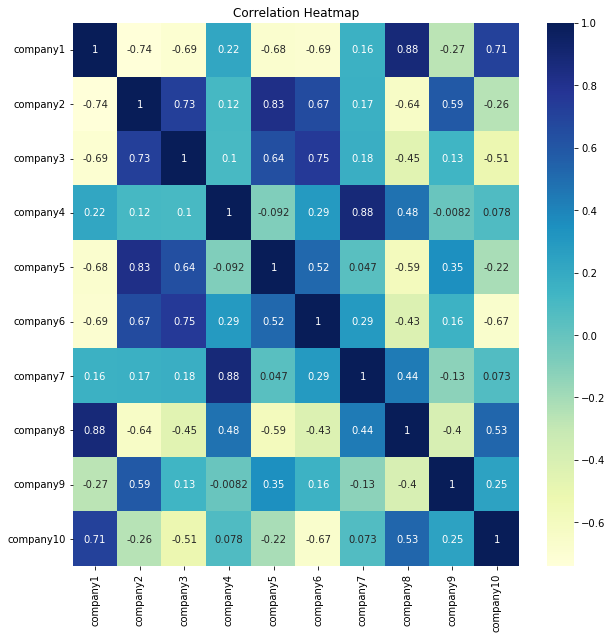

In [29]:
# Visualizing the data using a heatmap
plt.figure(figsize=(10, 10))
plt.title('Correlation Heatmap')
sns.heatmap(data.corr().loc[input_features, input_features],
            cmap="YlGnBu", annot=True)
plt.show()

<Figure size 360x360 with 0 Axes>

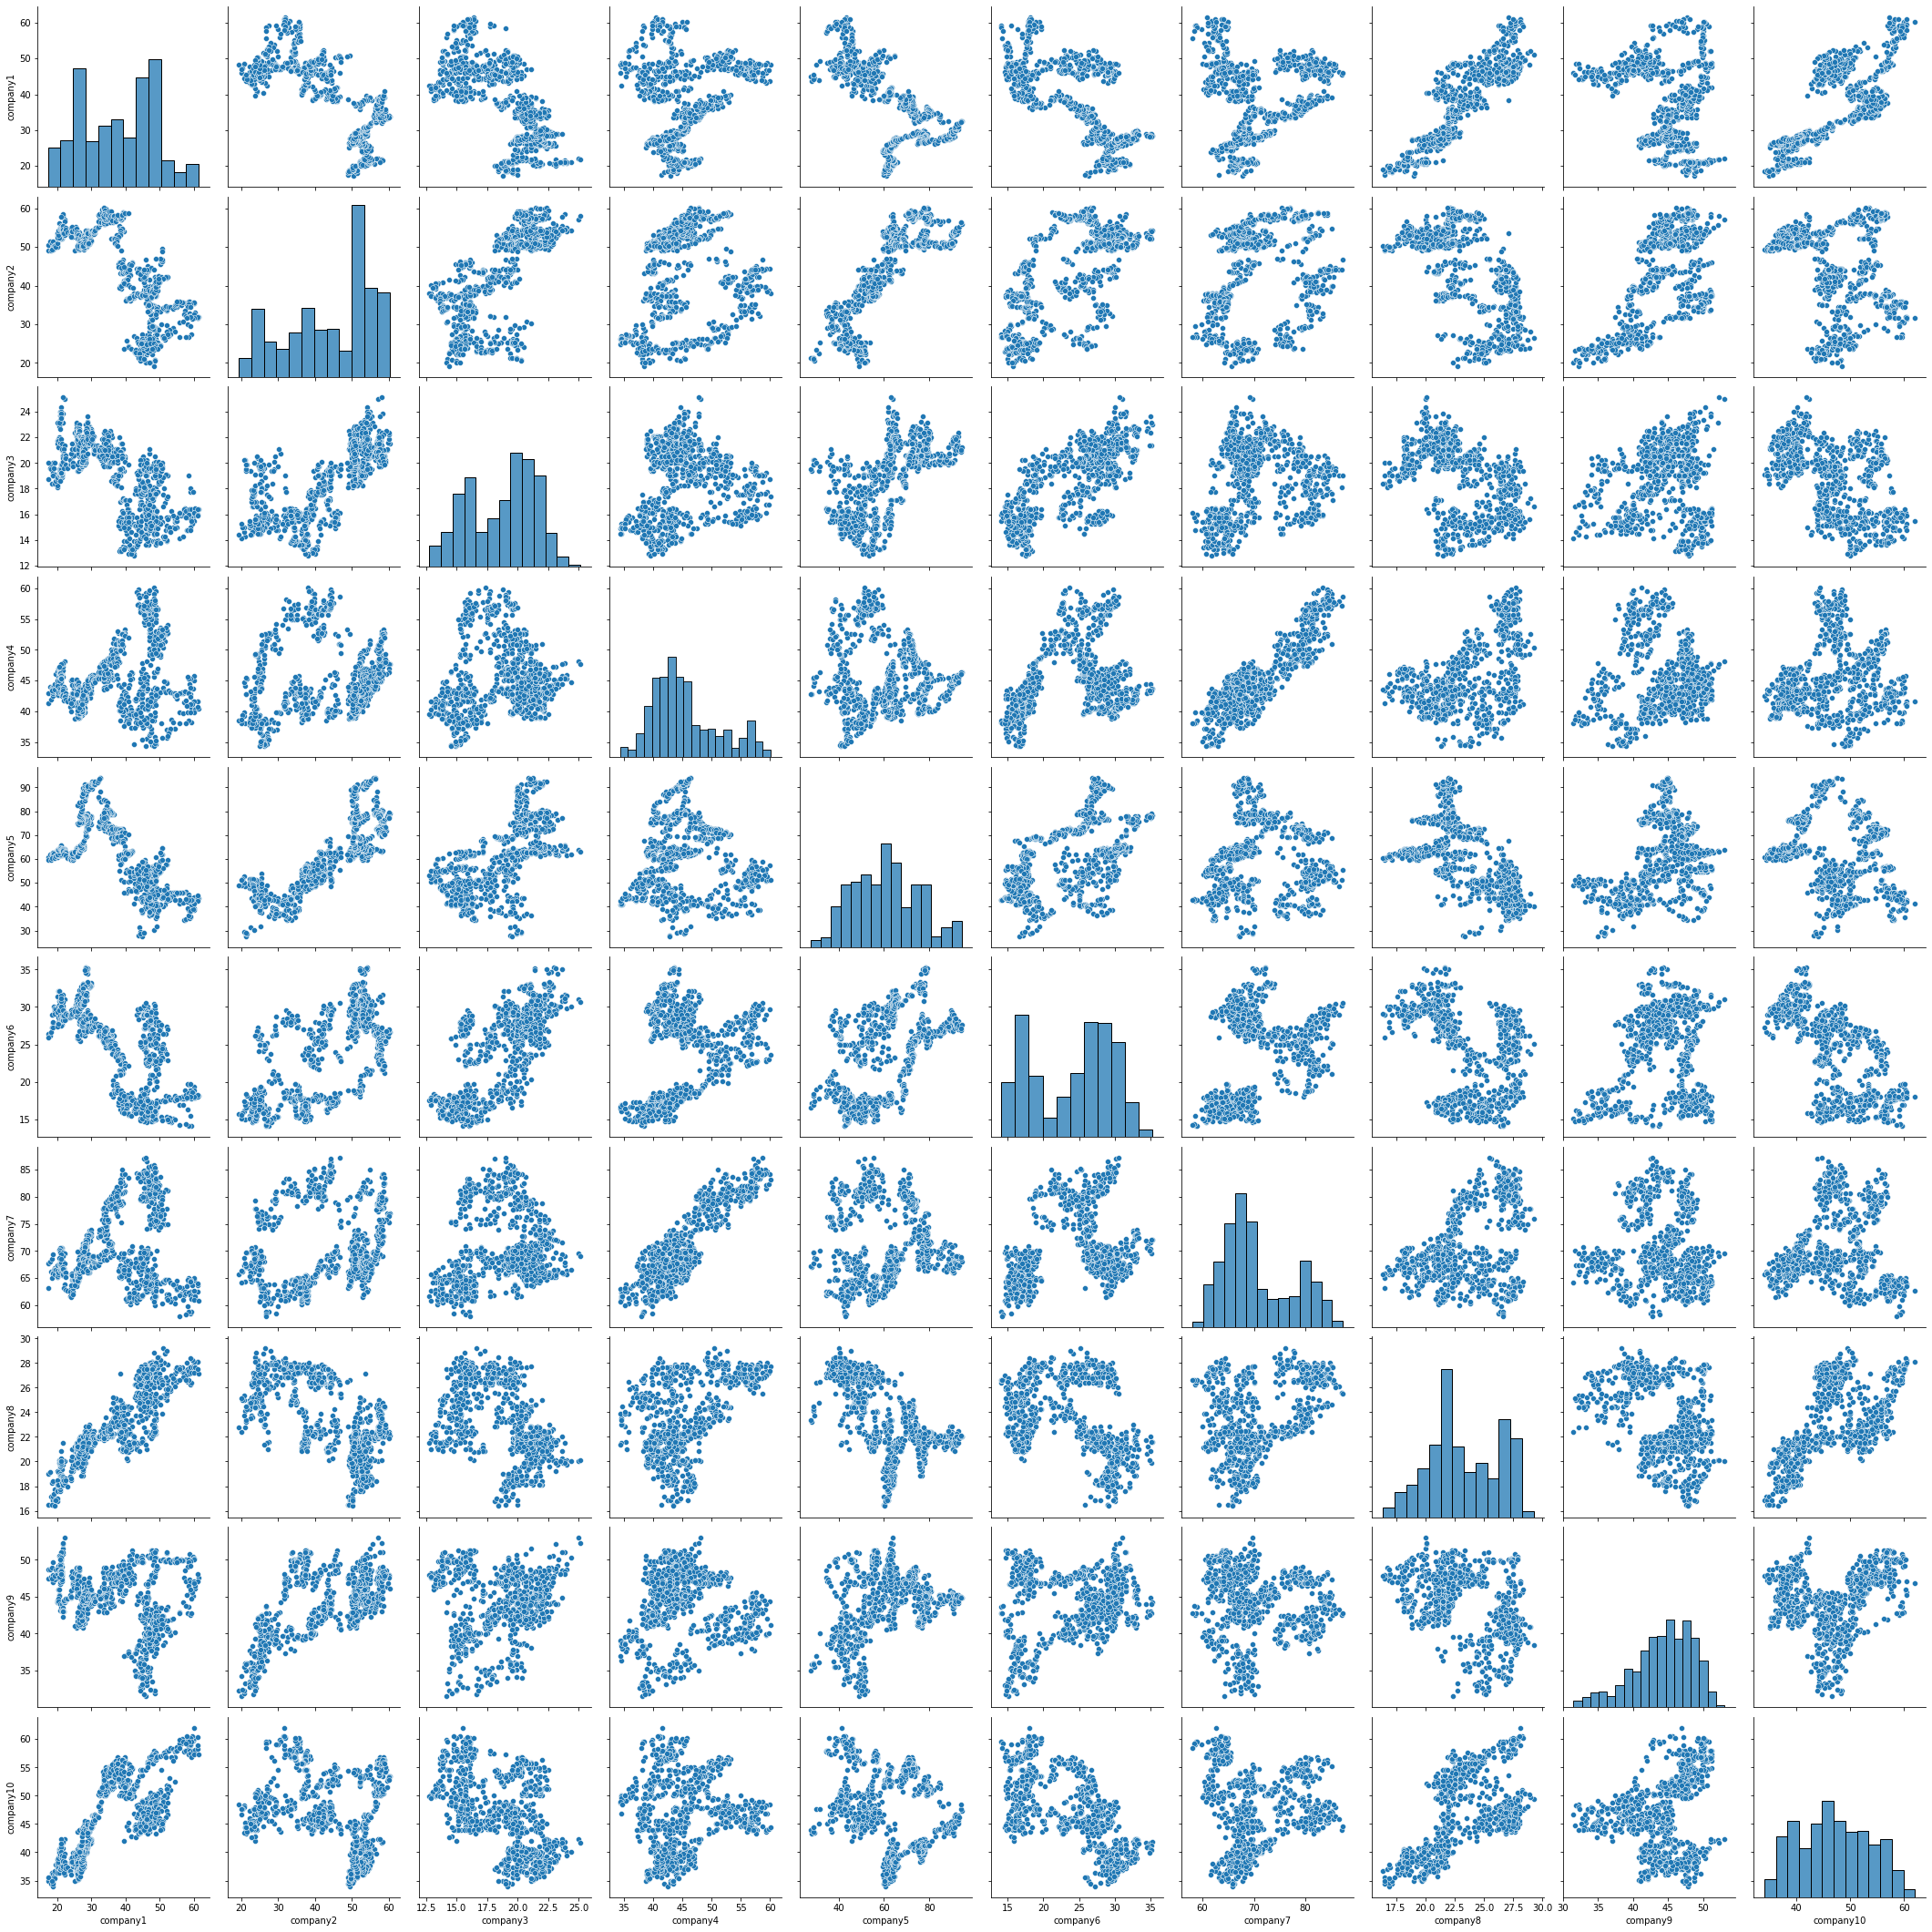

In [30]:
# Here we  visualize the correlation between input and dependent variable
plt.figure(figsize = (5, 5))
sns.pairplot(data, x_vars=input_features, y_vars=input_features, kind='scatter', height=3, aspect=1)
plt.show()

## Model Training: Regression
Now that we have looked at the data, it is time to define our regression tasks. We would like to predict the stock price of *company 10* given the price of *company 1*, *company 7* and *company 9*.

In [31]:
# Define ind. variables: company 1, 7 and 8
input_features = [col[0], col[6], col[8]]
X = data[input_features]
# Ind variable : company 10
y = data[col[-1]]

### Train and Test Split
Before moving on, we need to split the data into train and test subsets. 

In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size = 0.7, 
                                                    test_size = 0.3, random_state = 100)

### Training the linear Regression
Now we will fit the model based on our training data and retrieve the intercept and the coefficients of the linear regression.

In [33]:
from sklearn.linear_model import LinearRegression

# Defining a LinearRegression Model
model = LinearRegression()
model.fit(X_train, y_train)

# print the trained coefficients of the model
print(model.intercept_)
list(zip(input_features, model.coef_))

-1.304644248868037


[('company1', 0.5016772149800474),
 ('company7', -0.026758406605770668),
 ('company9', 0.7045236184863963)]

## Model Evaluation: Regression
For the evaluation of our regression model, we will look at the R squared value **(R2)**, the Mean Absolute Error **(MSA)**, the Mean Squared Error **(MSE)** and the Root Mean Squared Error **(RMSE)**. We will also plot the predictions we made against the actual values from our test set to visually inspect how well the model performed. Additionally, we plot the histogram of residual errors to see if it conforms to the normal distribution assumption.

In [34]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def evaluate_regression_metrics(y_test, predictions):
    # Get the main metrics and print them
    r2 = r2_score(y_test, predictions)
    msa = mean_absolute_error(y_test, predictions)
    mse = mean_squared_error(y_test, predictions, squared=True)
    rmse = mean_squared_error(y_test, predictions, squared=False)
    
    print('Evaluation Metrics Regression')
    print('-----------------------------')
    print(f'R2: {r2}')
    print(f'MSA: {msa}')
    print(f'MSE: {mse}')
    print(f'RMSE: {rmse} \n')

In [35]:
def plot_predicted(y_test, predictions):
    plt.figure(figsize=(10, 7))
    plt.title("Actual vs. Predicted Values", fontsize=25)
    plt.xlabel("Actual Test Set Values ", fontsize=18)
    plt.ylabel("Predicted Values", fontsize=18)
    plt.scatter(x=y_test, y=predictions)

In [36]:
def plot_residuals(y_test, predictions):
    plt.figure(figsize=(7, 5))
    plt.title("Histogram of Residuals", fontsize=25)
    plt.xlabel("Residuals", fontsize=18)
    plt.ylabel("Kernel density", fontsize=18)
    sns.histplot([y_test-predictions], kde=True)

In [37]:
def evaluate_regression(y_test, predictions):
    evaluate_regression_metrics(y_test, predictions)
    plot_predicted(y_test, predictions)
    plot_residuals(y_test, predictions)

Evaluation Metrics Regression
-----------------------------
R2: 0.7221299148929505
MSA: 3.031193025410934
MSE: 13.0863674544732
RMSE: 3.6175084594888234 



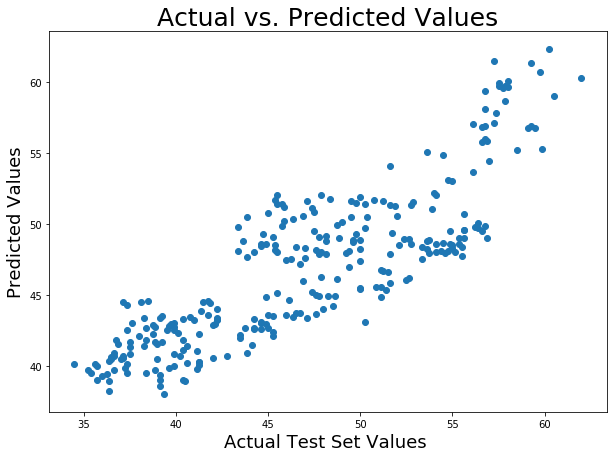

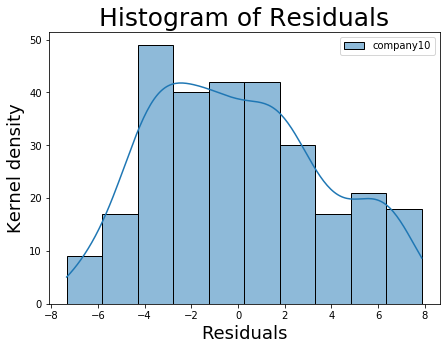

In [38]:
predictions = model.predict(X_test)
evaluate_regression(y_test, predictions)